# Reproducing results from Whipp et al. (2026)

This notebook contains the input files and model runs used to reproduce figures from:

Whipp, D. M., Gérard, B., Laaksonen, S., and Kellett, D. A.: Technical note: Tc1D - a 1D thermal and thermochronometer age prediction model, *EGUsphere* [preprint], https://doi.org/10.5194/egusphere-2026-2514, 2026.

The sections below are organized by figure.


# Figure 3,4,5 etc.

# Figure 8 - MCMC inversion of sample 18PE28

The complete MCMC inversion used for Figure 8 is computationally expensive and is not rerun in this notebook.

The thermochronological data for sample 18PE28 are from **Falkowski et al. (2023)**. The original MCMC input file and the thermochronological dataset used in Whipp et al. (2026) are provided here for reproducibility. The published MCMC diagnostic plots are displayed below.

The best-fitting forward model corresponding to the inversion result is then rerun to reproduce the forward-model outputs shown in Figure 8a–b.

**Data source:**

Falkowski, S., Ehlers, T. A., McQuarrie, N., Glover, C. O., Perez, N. D., and Buford Parks, V. M.: Exhumation and Incision of the Eastern Central Andes, Southern Peru: Low-temperature Thermochronology Observations, *Earth and Planetary Science Letters*, 620, 118299, https://doi.org/10.1016/j.epsl.2023.118299, 2023.

In [11]:
import pandas as pd

data_file = "Data_Whipp_Gerard_et_al_2026/figure_08_data.csv"

data = pd.read_csv(data_file)
data

,Age type,Age (Ma),Standard deviation (Ma),eU concentration (ppm),Grain radius (um),Sample ID,Depositional age (Ma)
0,AHe,1.0,0.04,496.5,71.8,18PE28a_1,NaN
1,AHe,1.2,0.04,369.0,84.4,18PE28a_2,NaN
2,AHe,1.8,0.20,310.2,99.7,18PE28a_3,NaN
3,AHe,2.1,0.10,109.8,100.9,18PE28a_4,NaN
4,AFT,5.0,2.90,NaN,NaN,18PE28aft_01,NaN
5,AFT,3.4,1.10,NaN,NaN,18PE28aft_02,NaN
6,AFT,4.3,1.90,NaN,NaN,18PE28aft_03,NaN
7,AFT,2.0,0.80,NaN,NaN,18PE28aft_04,NaN
8,AFT,4.0,2.90,NaN,NaN,18PE28aft_05,NaN
9,AFT,3.2,1.30,NaN,NaN,18PE28aft_06,NaN


## MCMC inversion configuration

The YAML file below contains the complete T<sub>c</sub>1D configuration used for the Figure 8 MCMC inversion.

In [12]:
from pathlib import Path

mcmc_yaml = Path("Data_Whipp_Gerard_et_al_2026/figure_08_mcmc.yaml")

print(mcmc_yaml.read_text())

# Tc1D input file for Whipp et al. (2026), Figure 8
#
# MCMC inversion of sample 18PE28 (Falkowski et al., 2023).
# Scientific parameter values are retained from the original publication run.
# Syntax has been updated for the current Tc1D develop branch.
#
# Thermal/crustal parameters marked below follow Gérard et al. (2021)
#
# Main units:
# time, start times, durations : Myr
# dt                          : years
# length/depth/thickness       : km
# density                      : kg m^-3
# heat capacity                : J kg^-1 K^-1
# thermal conductivity         : W m^-1 K^-1
# heat production              : microW m^-3
# temperature                  : degrees C
# velocity                     : mm yr^-1
# grain radius                 : micrometres
# U, Th                        : ppm

# ==============================================================================
# 1) General / run control
# ==============================================================================
general:
  r

## Reproducing the MCMC inversion

The full MCMC inversion can be reproduced from the command line using:

```bash
tc1d-cli --input-file Data_Whipp_Gerard_et_al_2026/figure_08_mcmc.yaml

### MCMC inversion results

The diagnostic plots below are outputs from the original MCMC inversion used for Figure 8. They are provided here because the full publication inversion is computationally expensive and is not rerun automatically in this notebook.

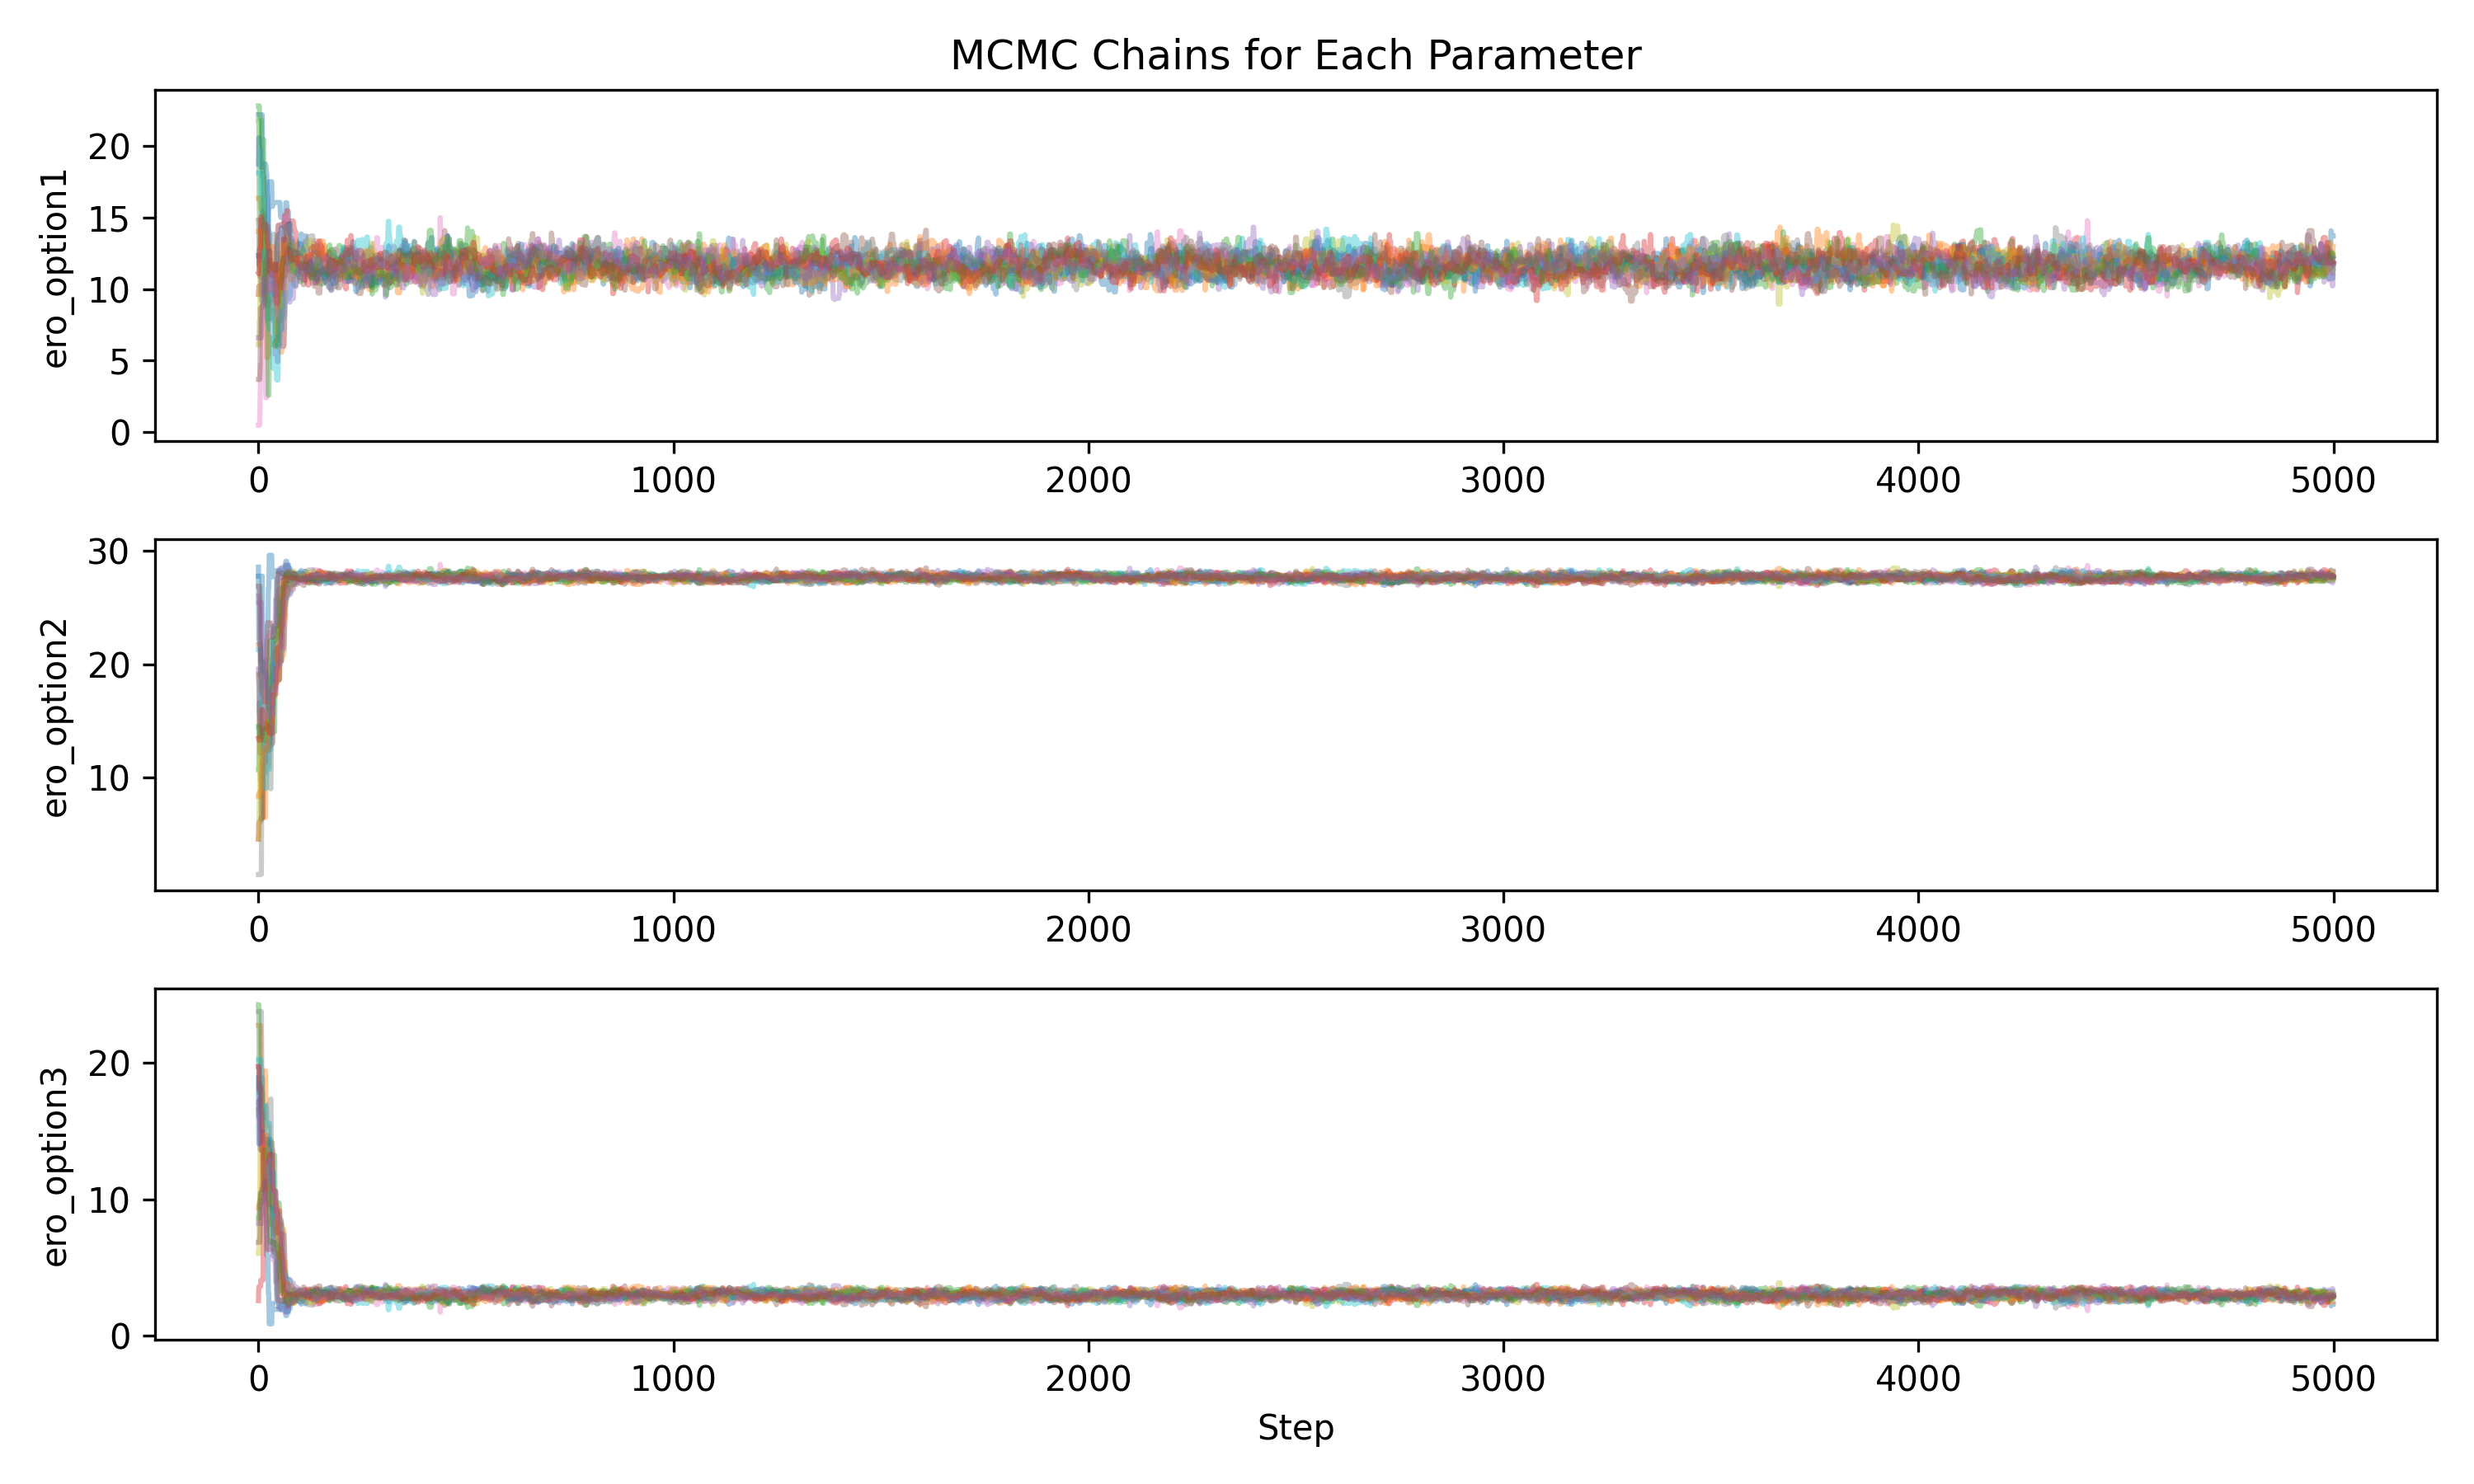

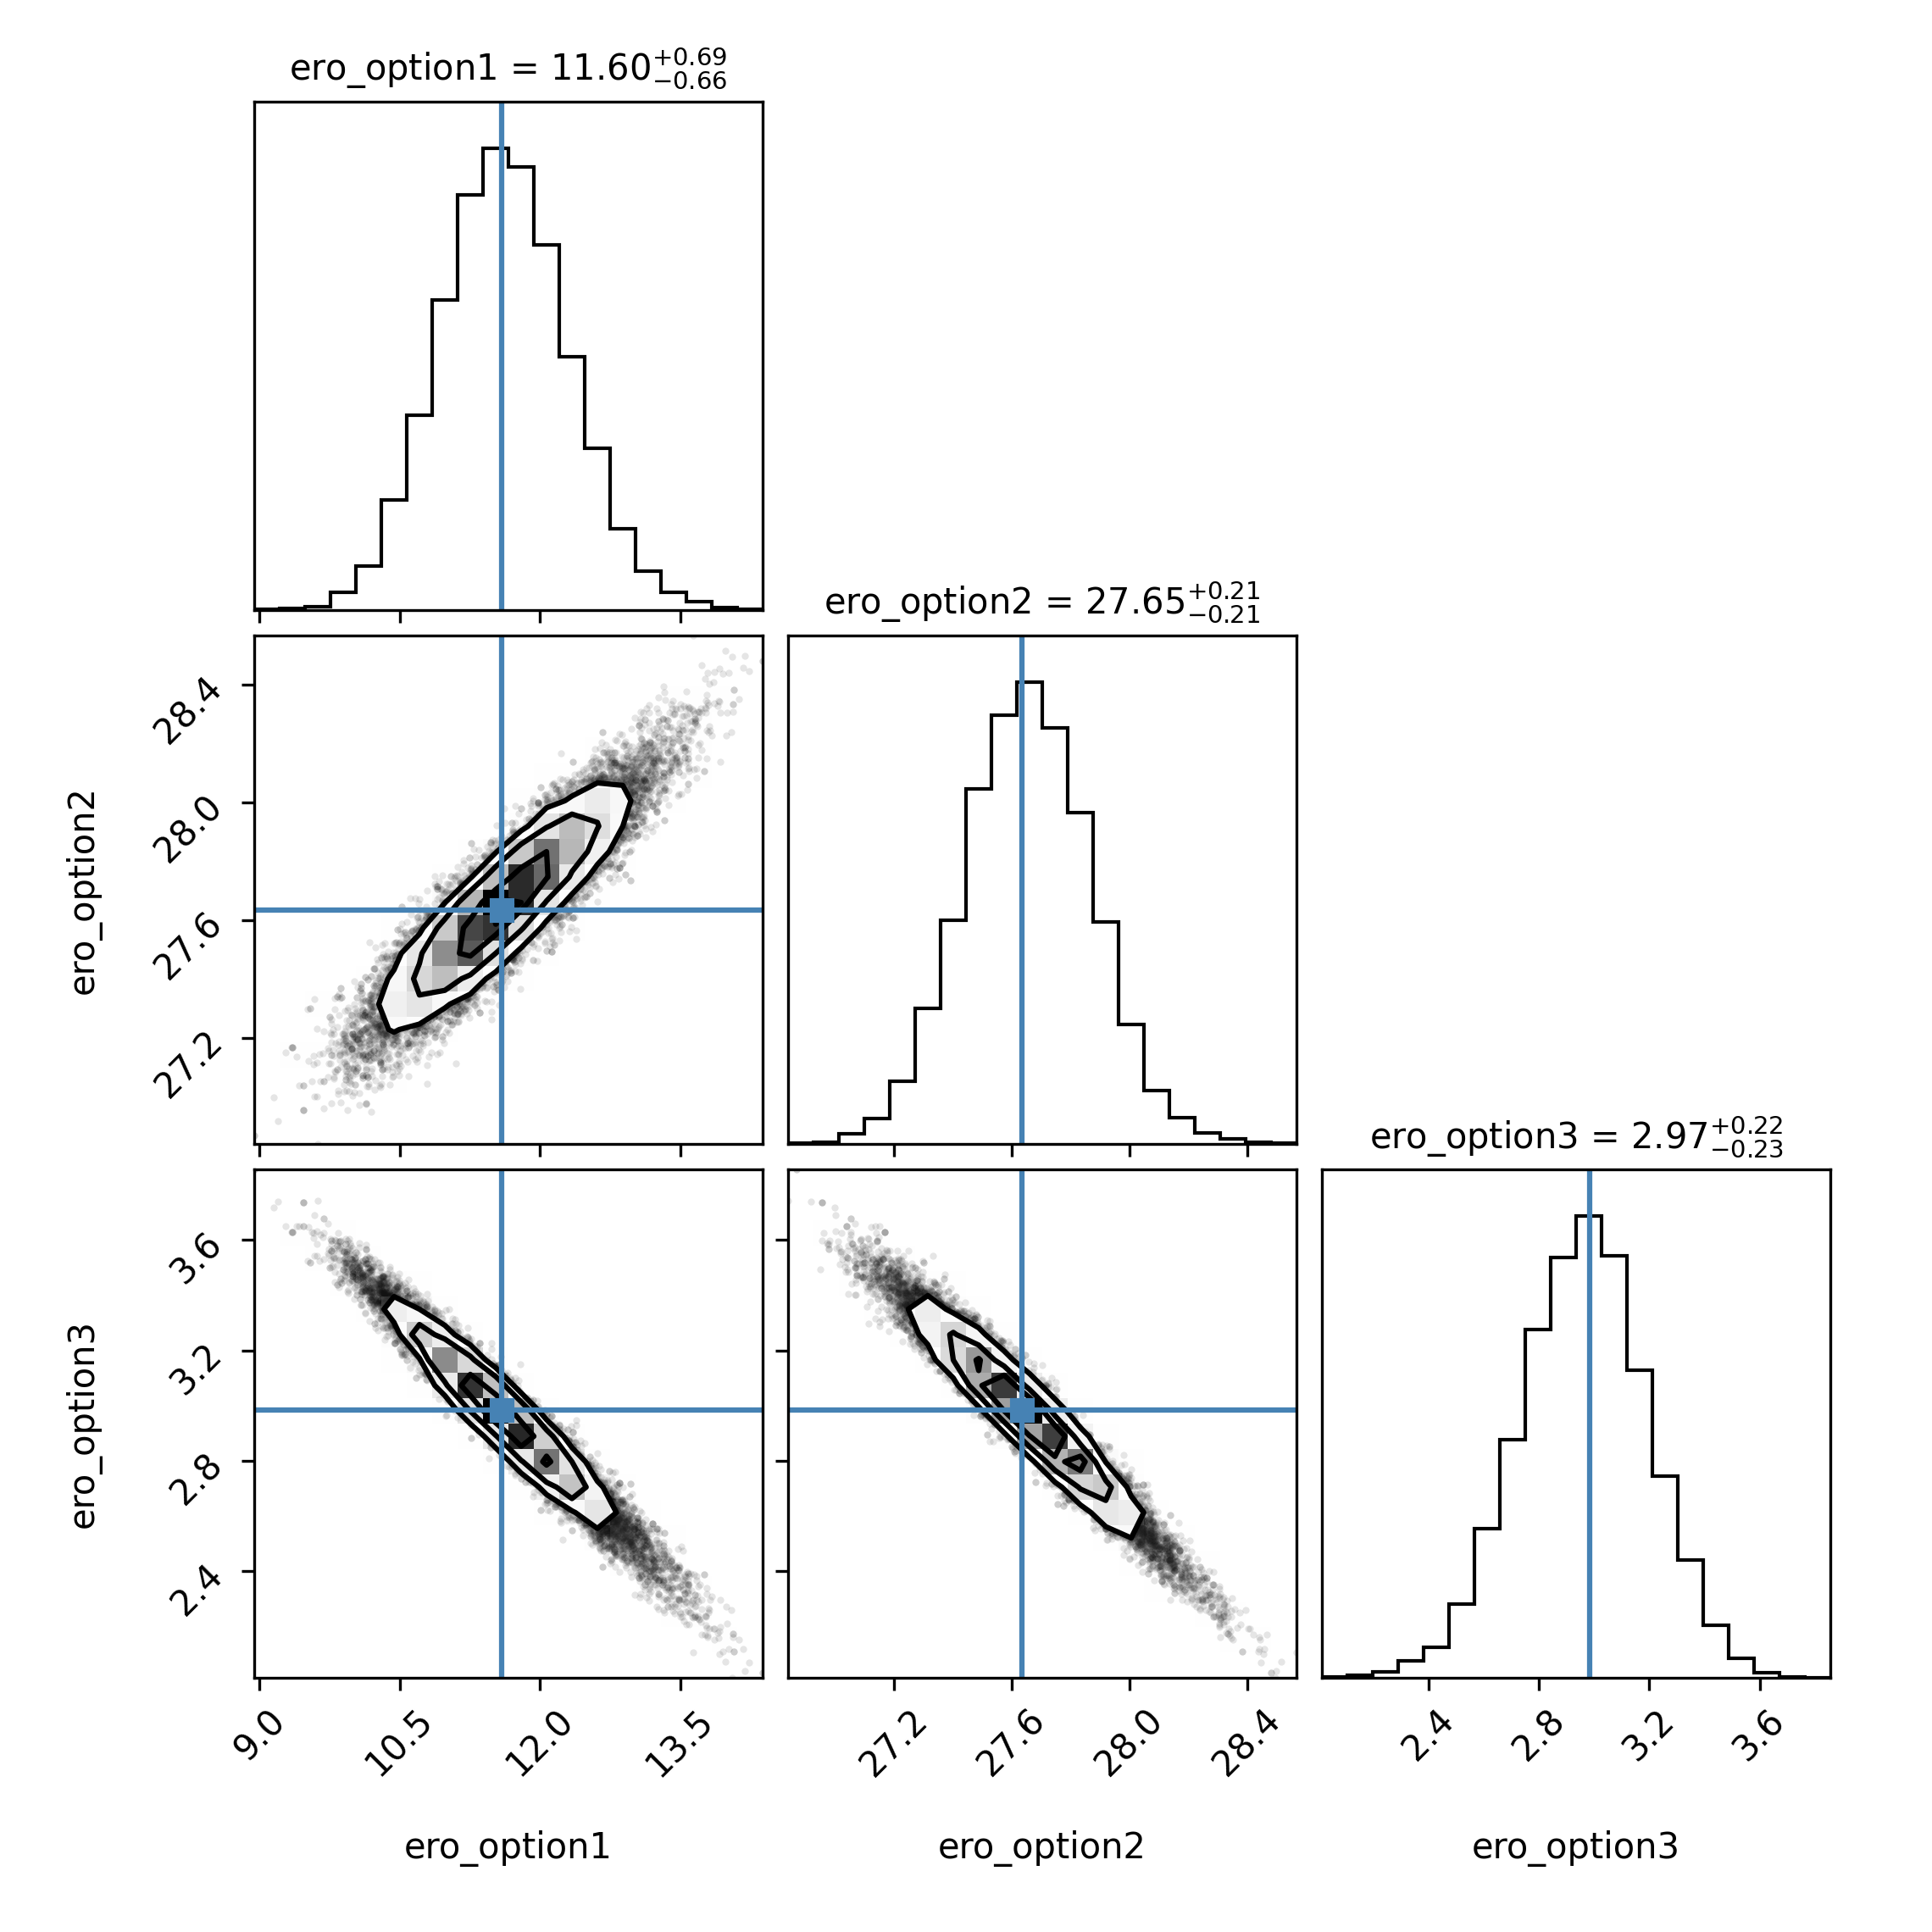

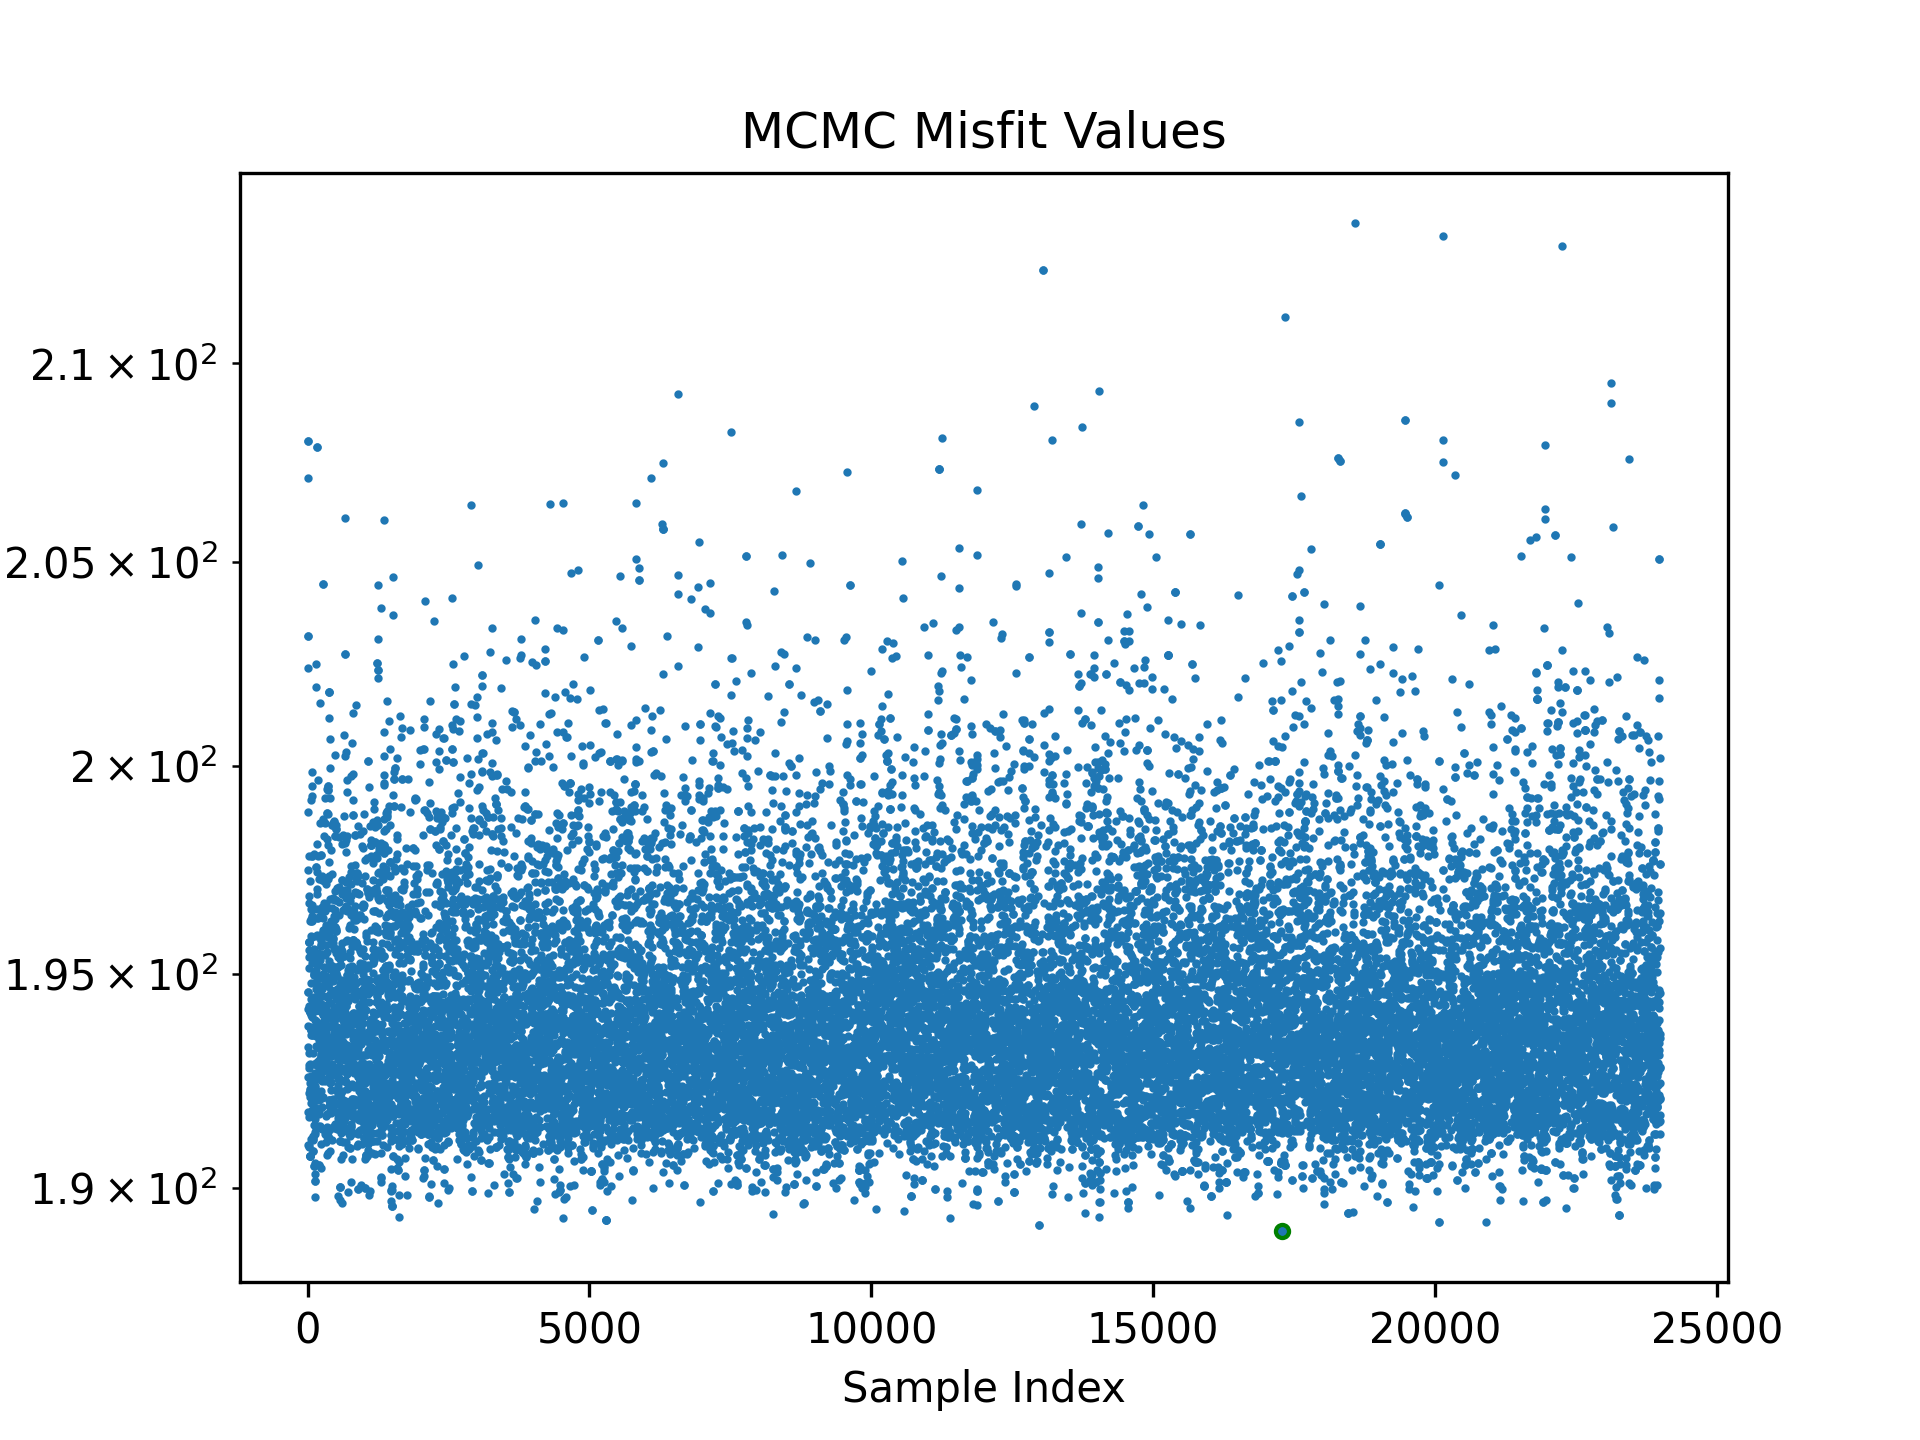

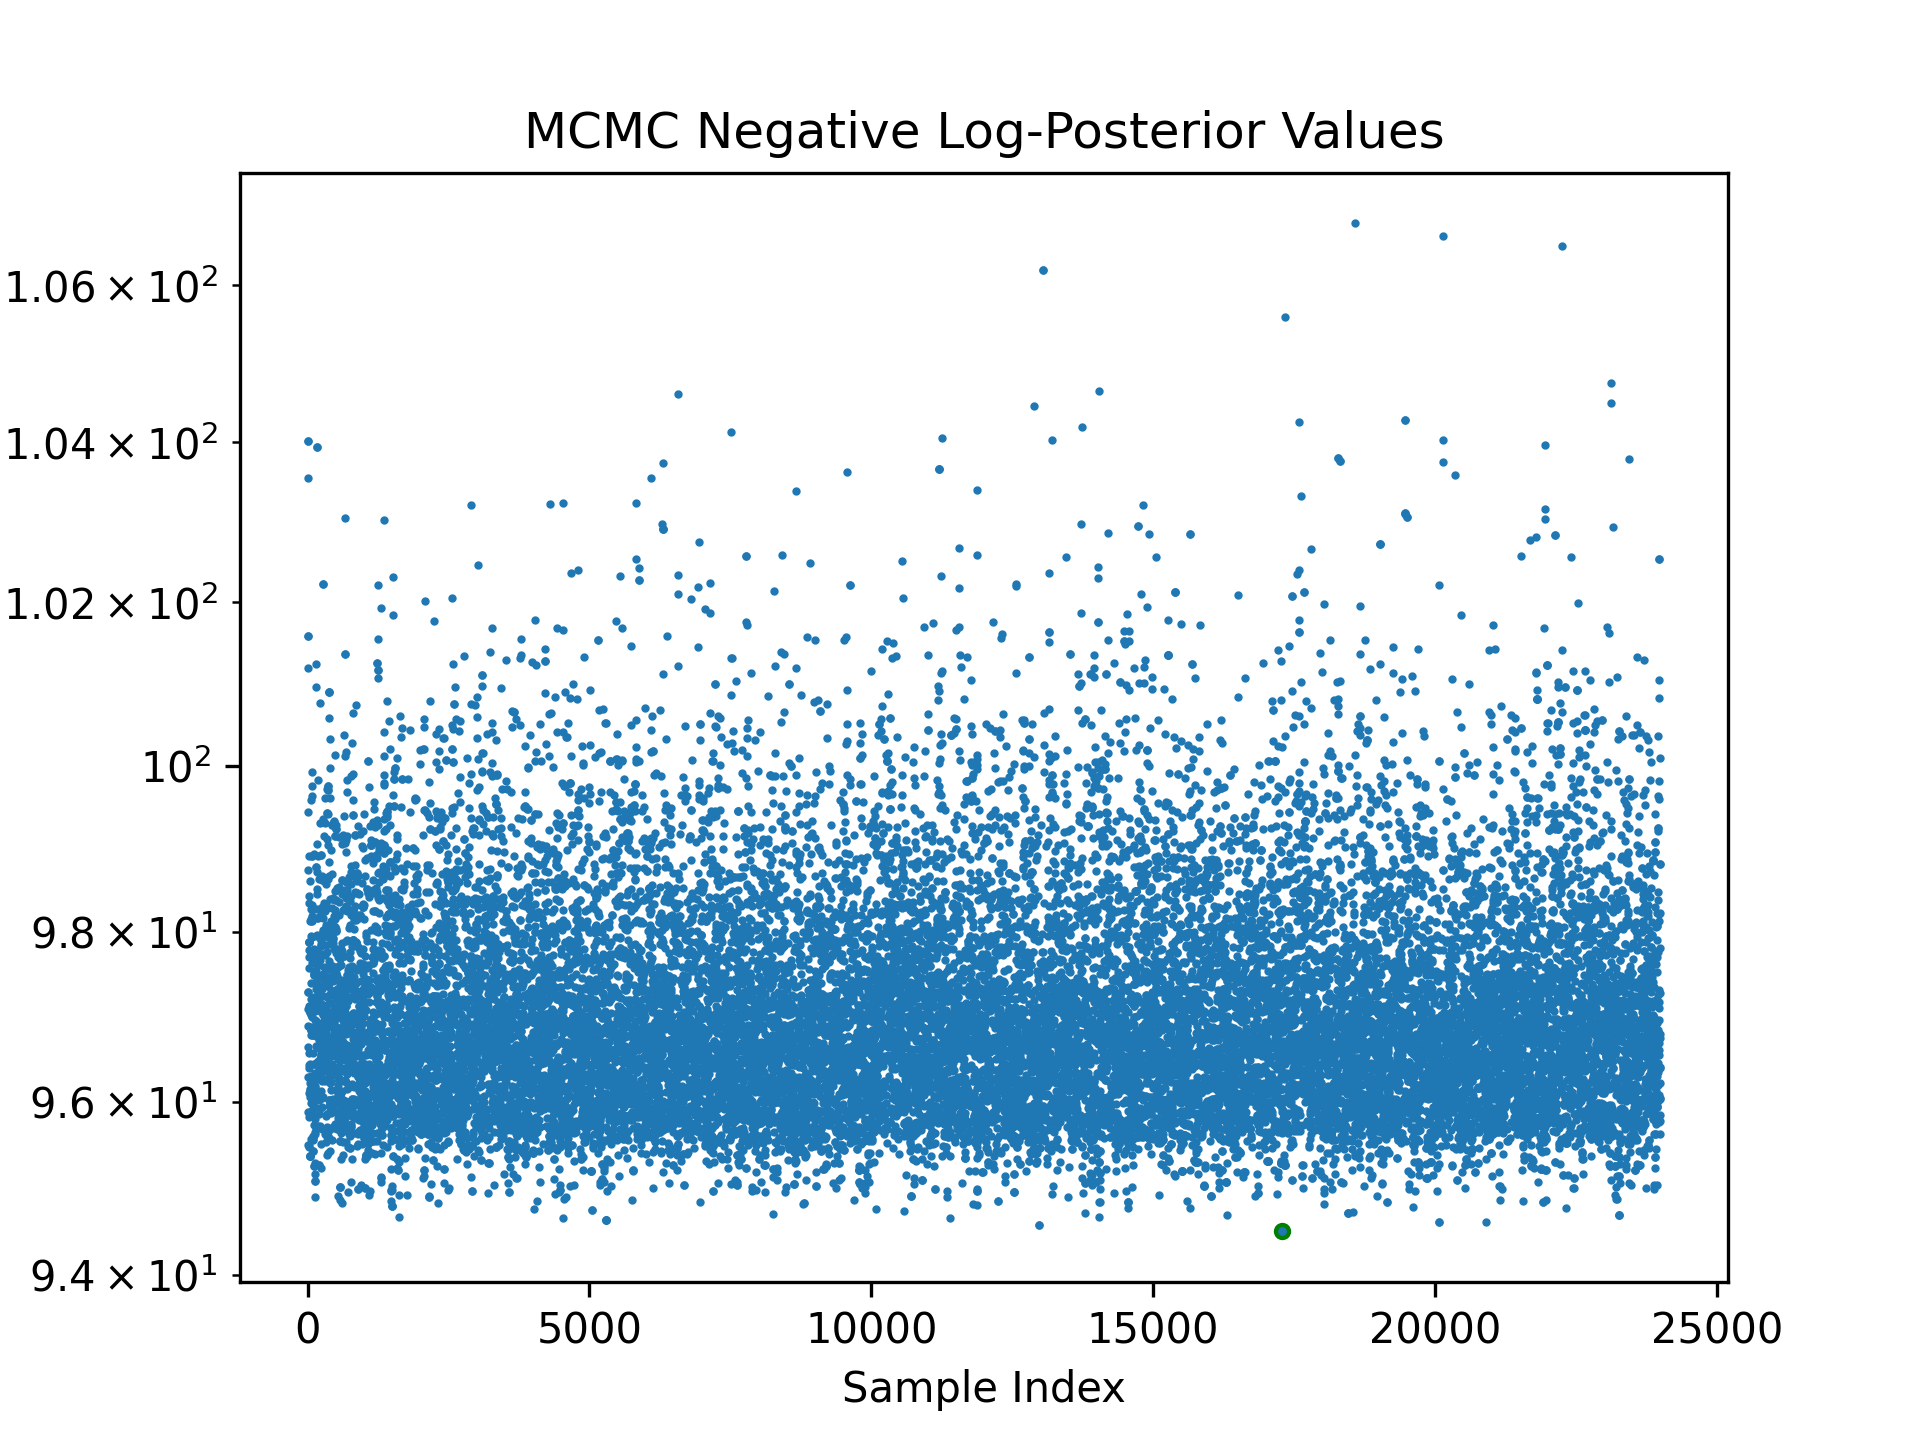

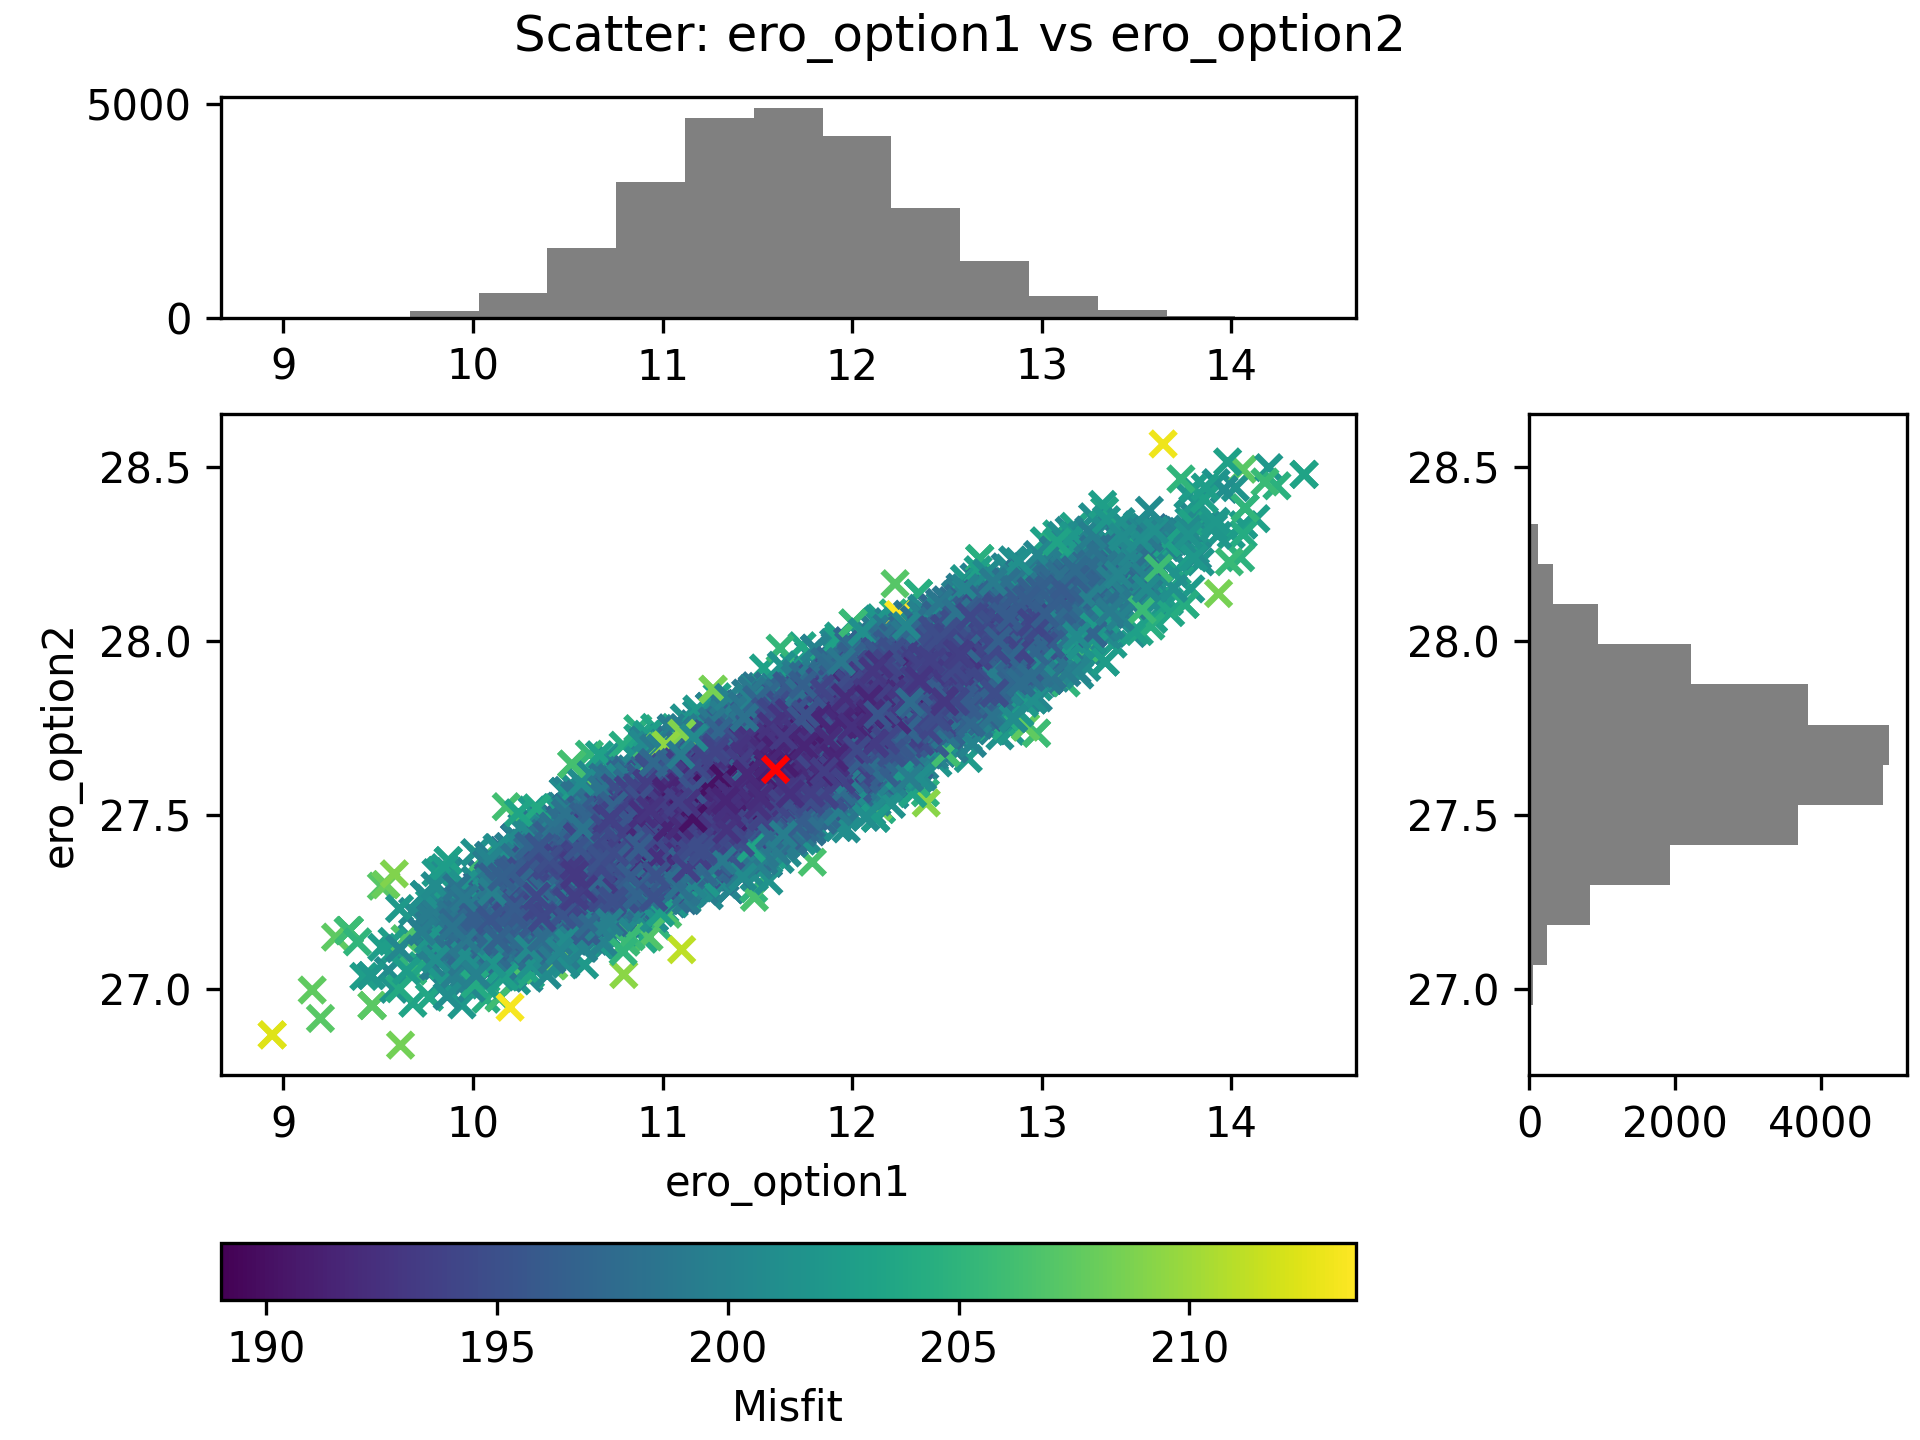

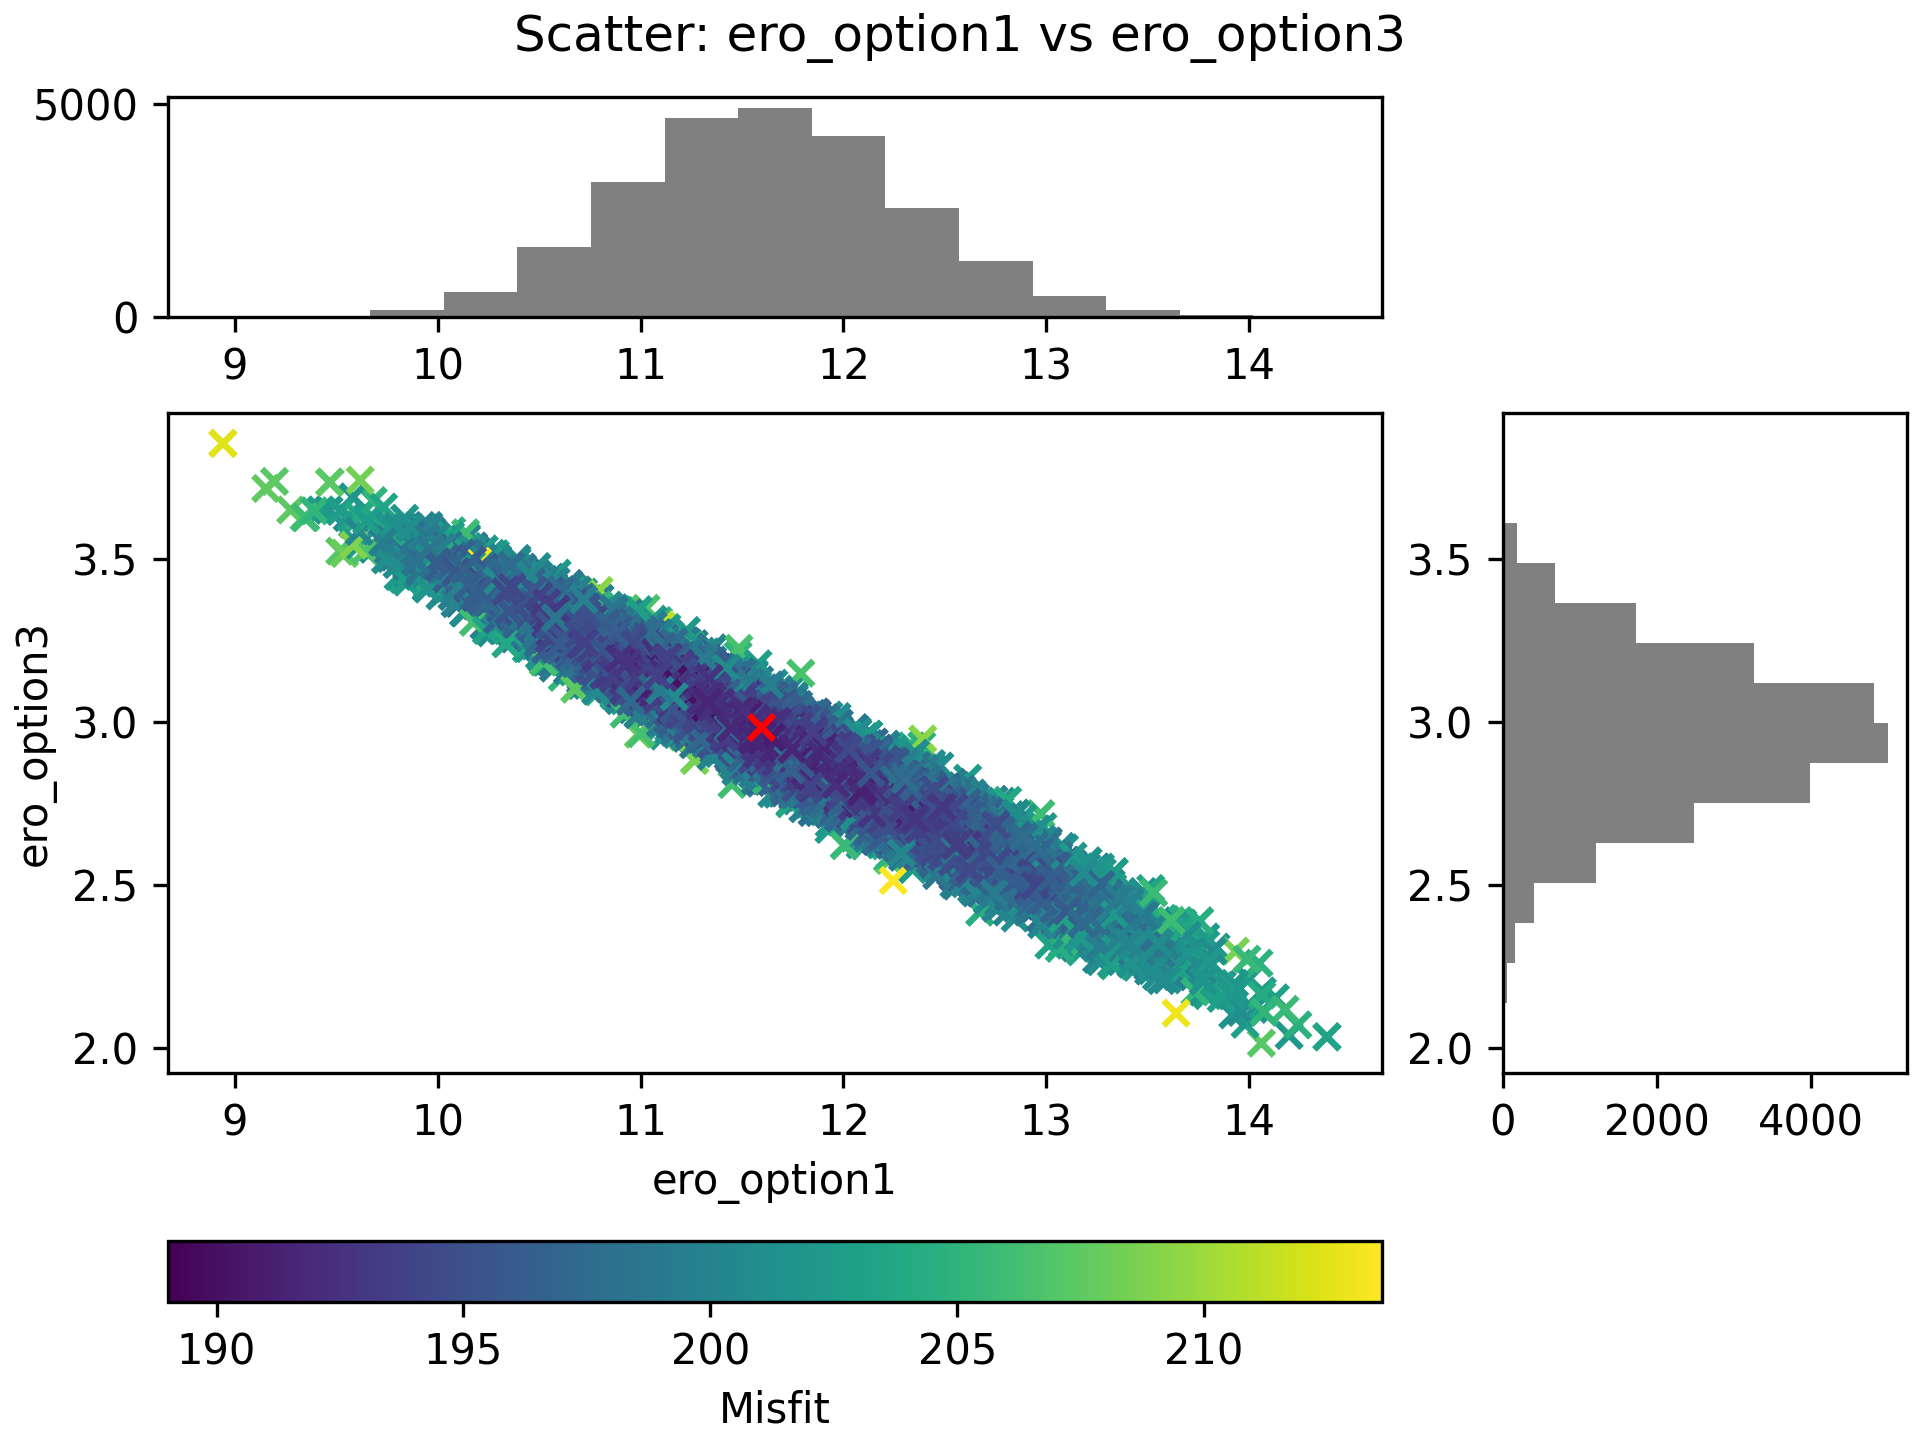

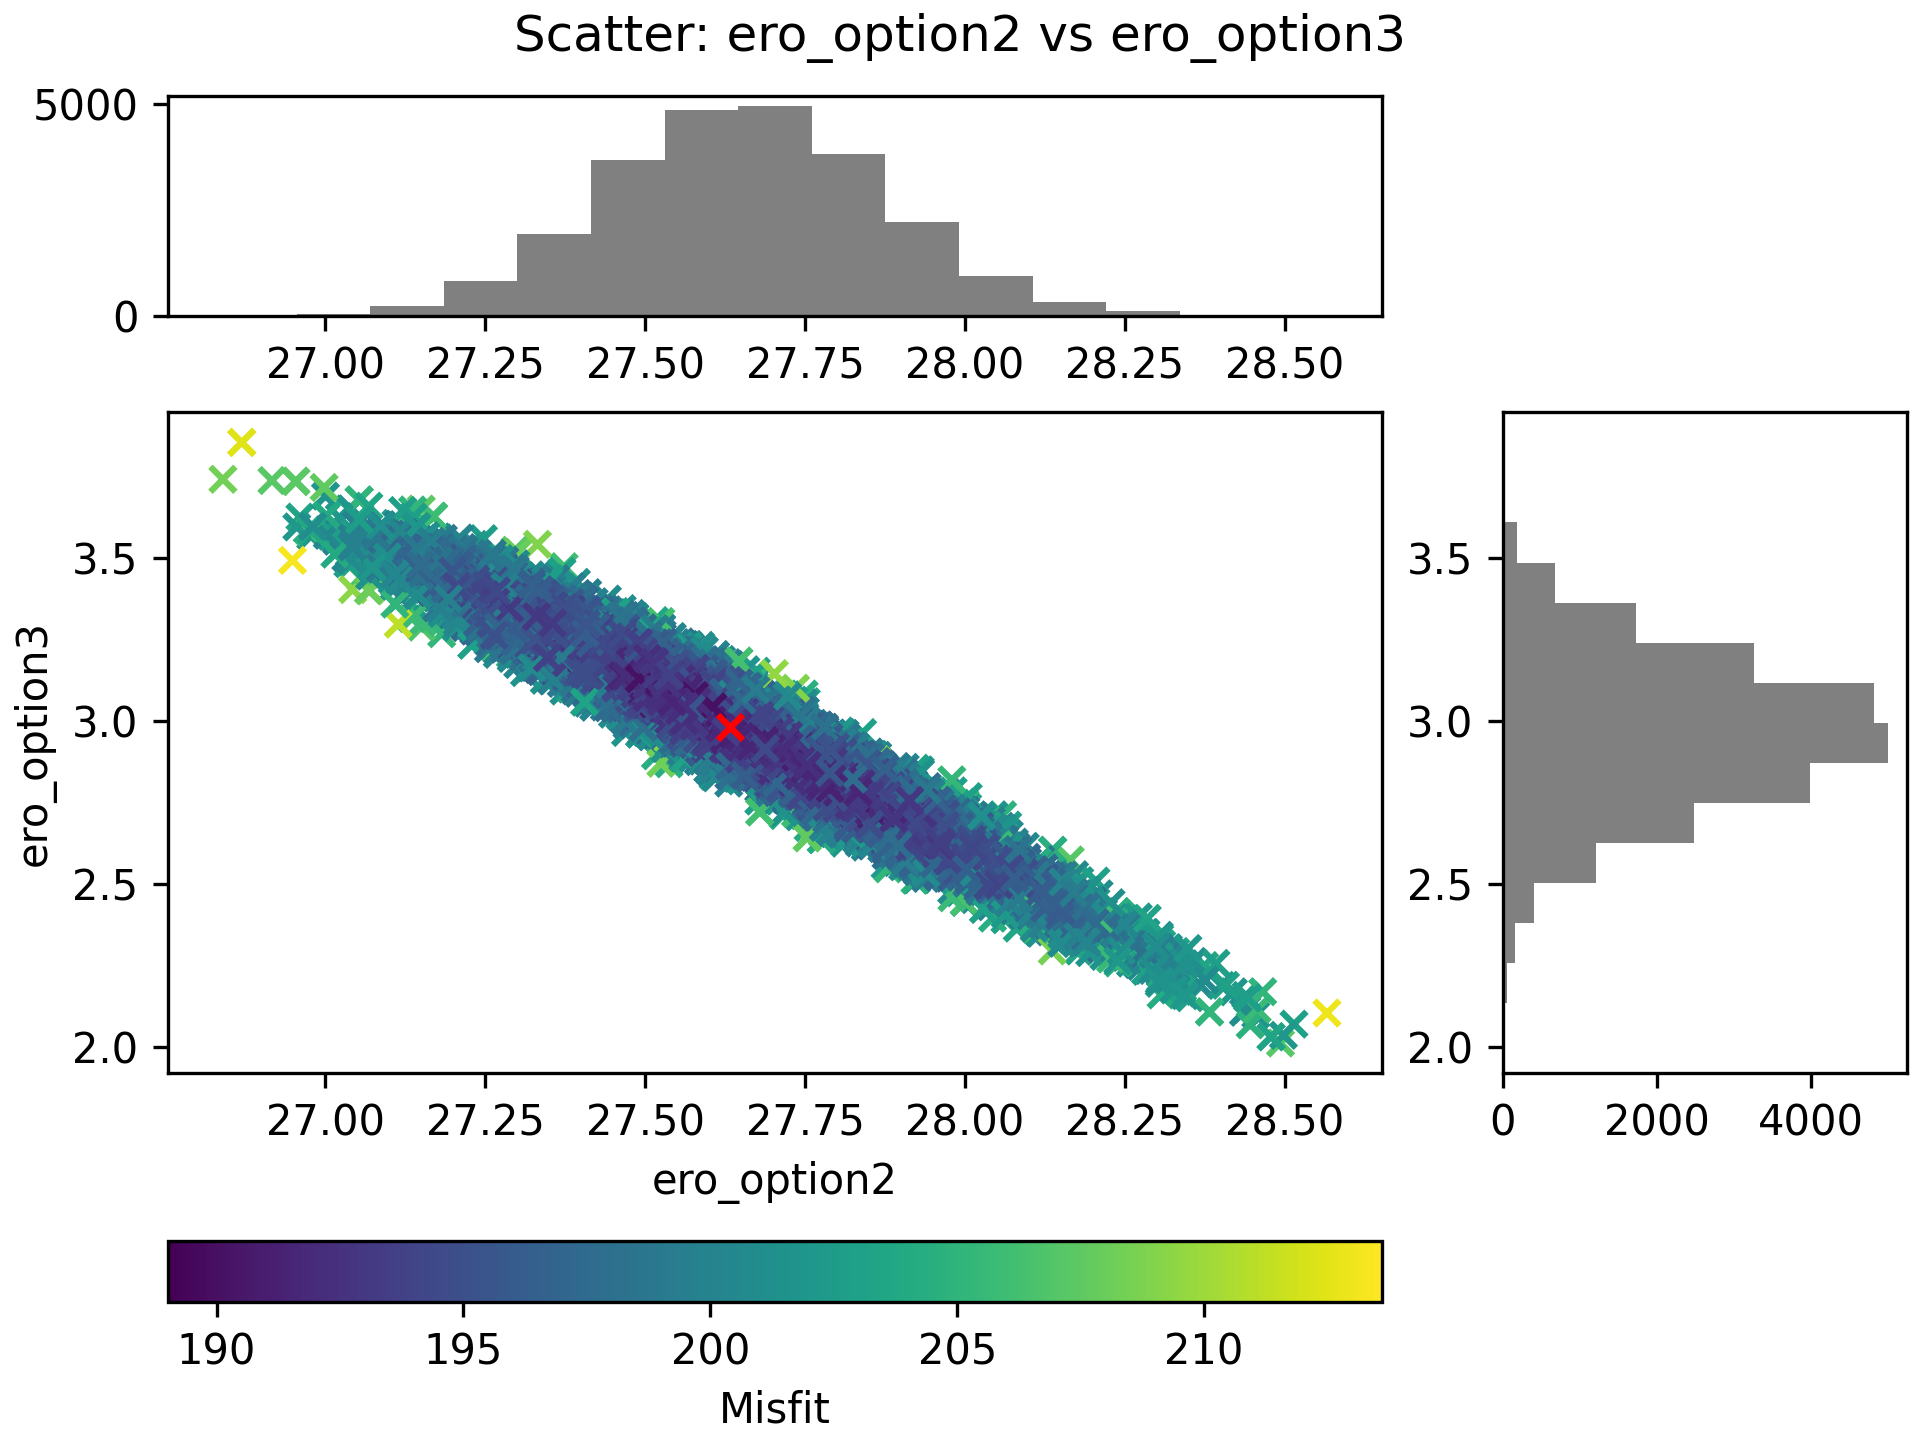

In [13]:
from pathlib import Path
from IPython.display import Image, display

mcmc_output_dir = Path(
    "Data_Whipp_Gerard_et_al_2026/figure_08_mcmc_outputs"
)

mcmc_figures = [
    "mcmc_chains.png",
    "mcmc_corner.png",
    "mcmc_misfit.png",
    "mcmc_neg_log_posterior.png",
    "mcmc_scatter_ero_option1_vs_ero_option2.png",
    "mcmc_scatter_ero_option1_vs_ero_option3.png",
    "mcmc_scatter_ero_option2_vs_ero_option3.png",
]

for figure in mcmc_figures:
    display(Image(filename=mcmc_output_dir / figure))

## Best-fitting forward model

The YAML file below contains the best-fitting forward-model parameters derived from the Figure 8 MCMC inversion.

This forward model is rerun here to reproduce the Tc1D outputs shown in Figure 8a–b.

In [14]:
from pathlib import Path

forward_yaml = Path(
    "Data_Whipp_Gerard_et_al_2026/figure_08_forward.yaml"
)

print(forward_yaml.read_text())

# Tc1D input file for Whipp et al. (2026), Figure 8
#
# Best-fitting forward model corresponding to the Figure 8 MCMC inversion.
# Scientific parameter values are retained from the original publication run.
# Syntax has been updated for the current Tc1D develop branch.
#
# Thermal/crustal parameters marked below follow Gérard et al. (2021).

# ==============================================================================
# 1) General / run control
# ==============================================================================
general:
  run_type: "forward"
  batch_mode: false
  inverse_mode: false
  debug: false

  echo_inputs: false
  no_echo_info: true
  no_echo_thermal_info: true
  no_echo_ages: true

# ==============================================================================
# 2) Geometry and time
# ==============================================================================
geometry_time:
  length: 125.0
  nx: 251
  time: 30.0
  dt: 20000.0

  init_moho_depth: 60.0        

In [15]:
!tc1d-cli --input-file Data_Whipp_Gerard_et_al_2026/figure_08_forward.yaml


========================== This is Tc1D version 0.4.1 ==========================

----------------------- Forward model execution started ------------------------

--- Calculating initial thermal model ---


--- Calculating transient thermal model (Pass 1/1) ---

- Step  1500 of 1500 (Time:  30.0 Myr, Erosion rate:  1.26 mm/yr)


--- Writing output file(s) ---

- Temperature history plot written to /Users/gerardb/Projects/Tc1D/notebooks/publication_notebooks/png/temperature_history.png
- Thermal history and ages plot written to /Users/gerardb/Projects/Tc1D/notebooks/publication_notebooks/png/thermal_history.png

------------------ Execution completed in     1.6270 seconds -------------------


### Best-fitting forward-model results

The figures below are generated by rerunning the best-fitting forward model and reproduce the thermal and thermochronological model outputs associated with Figure 8a–b.

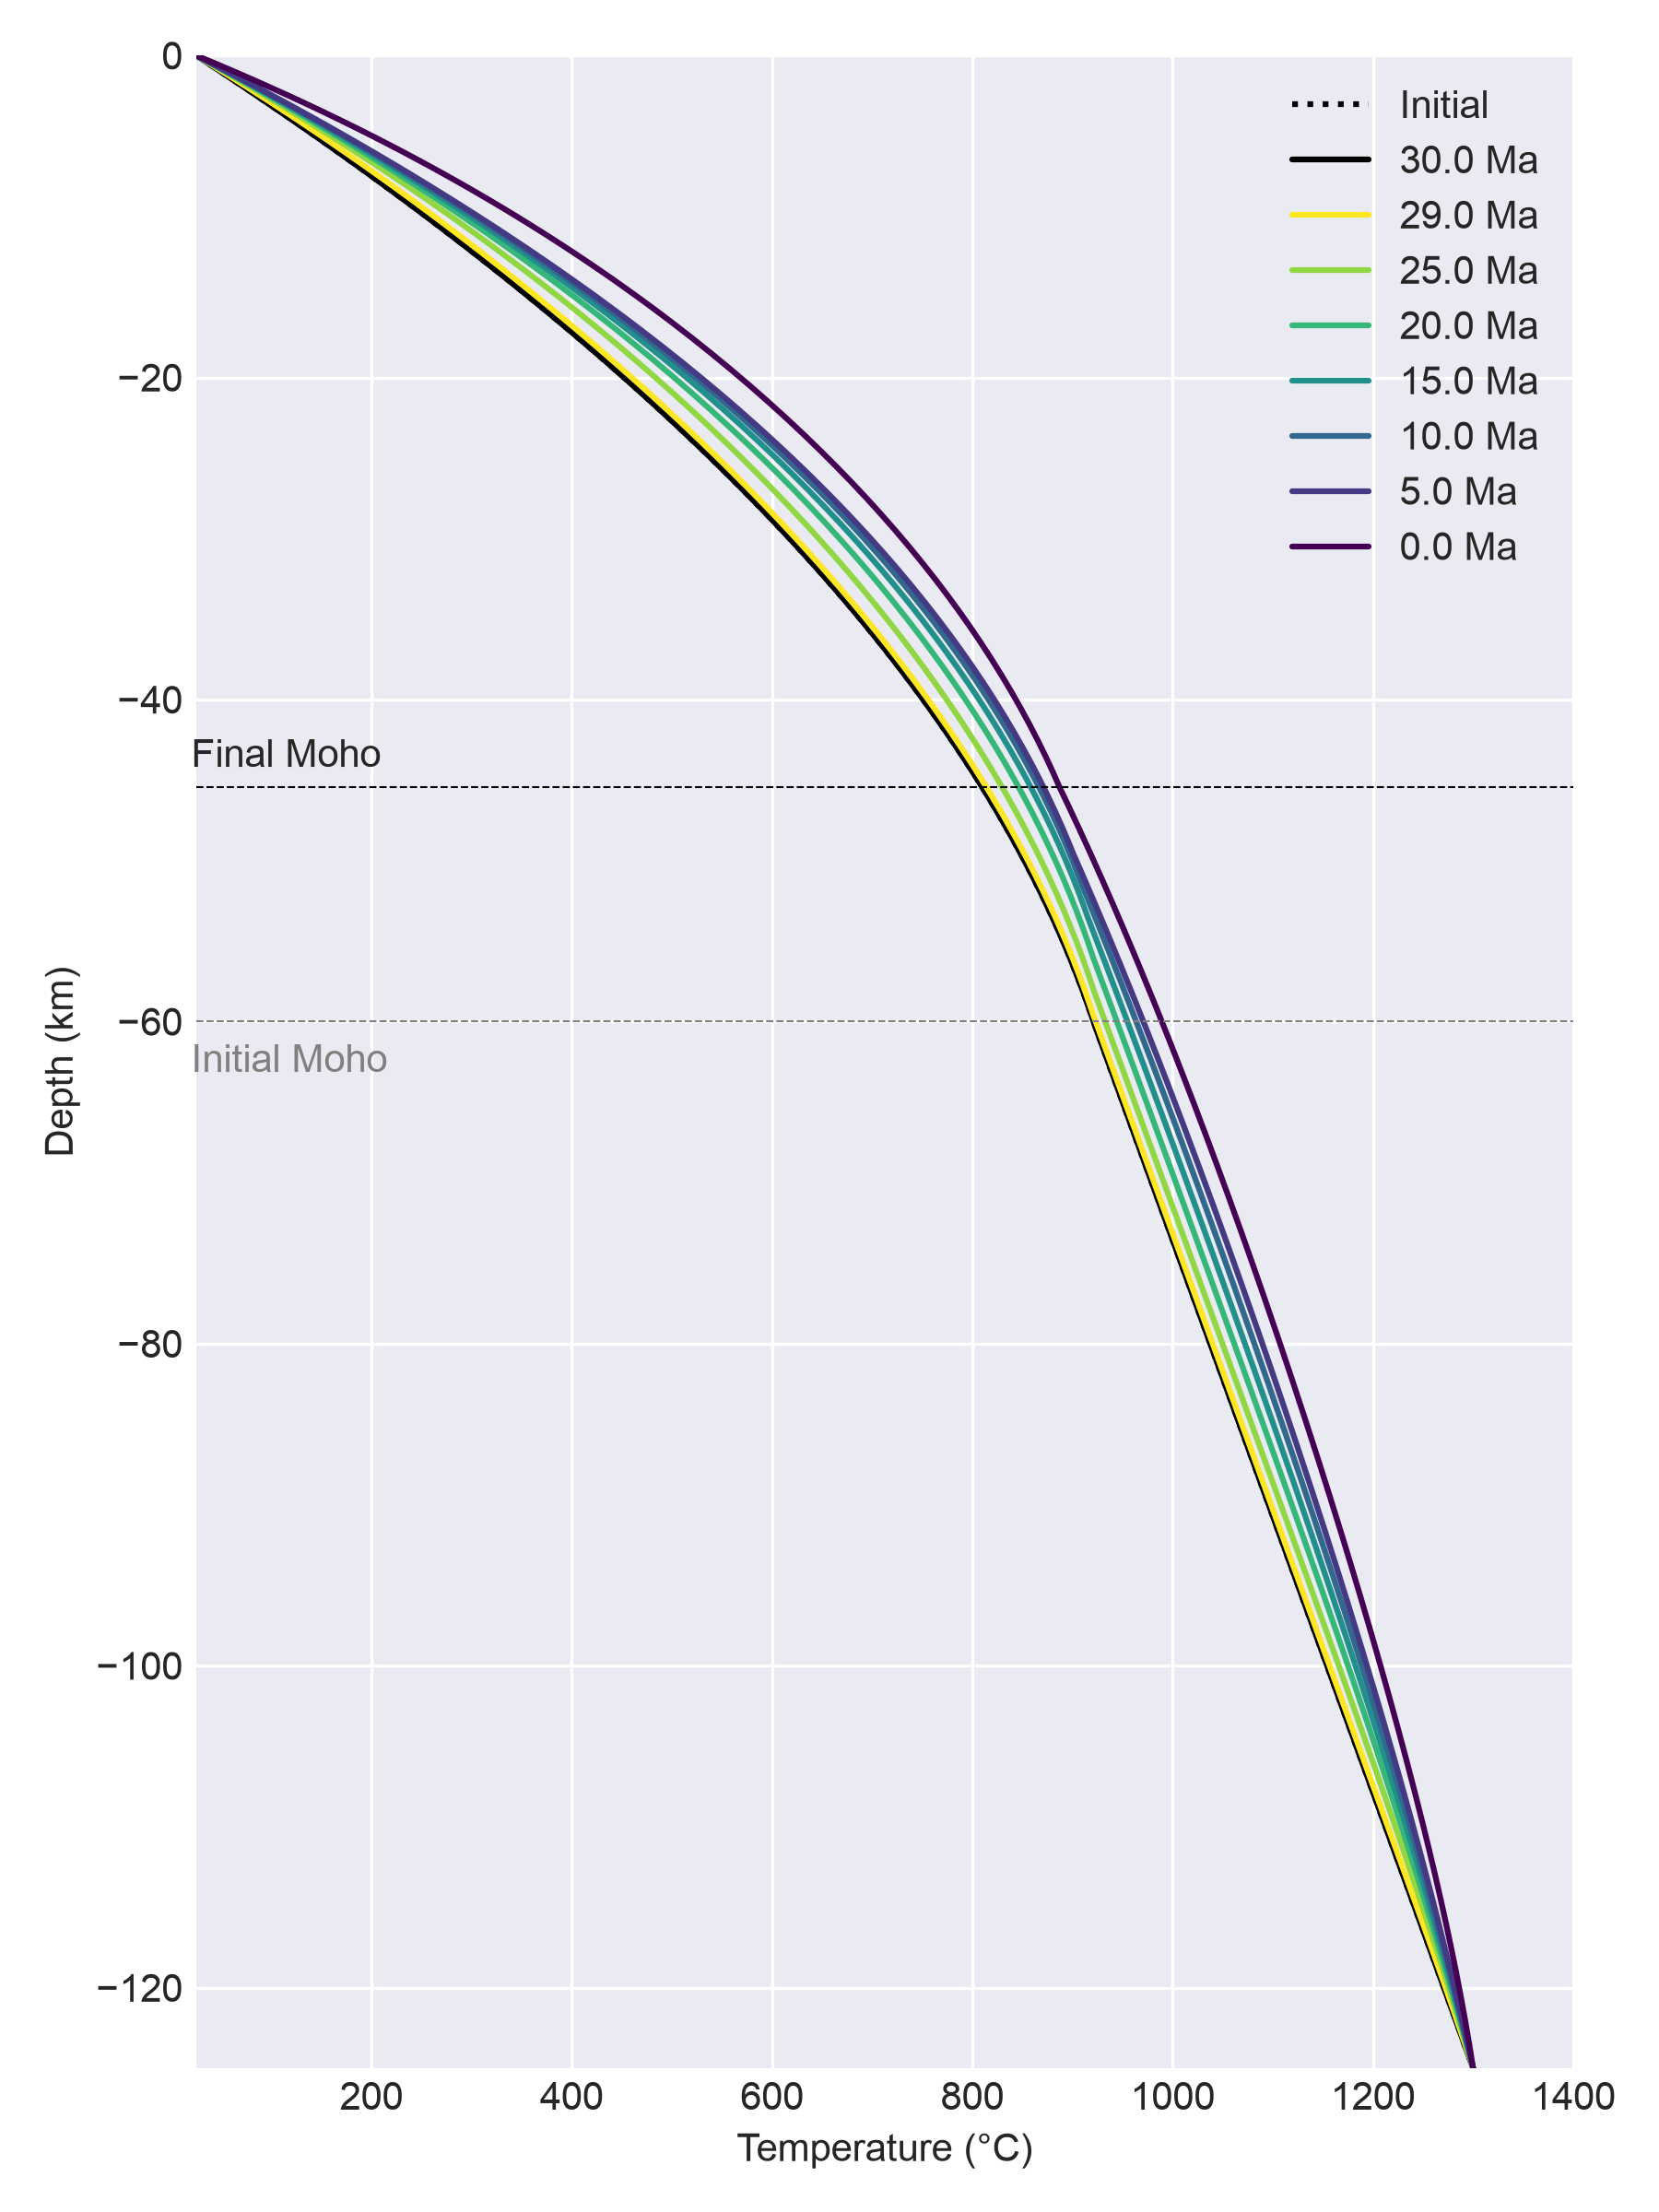

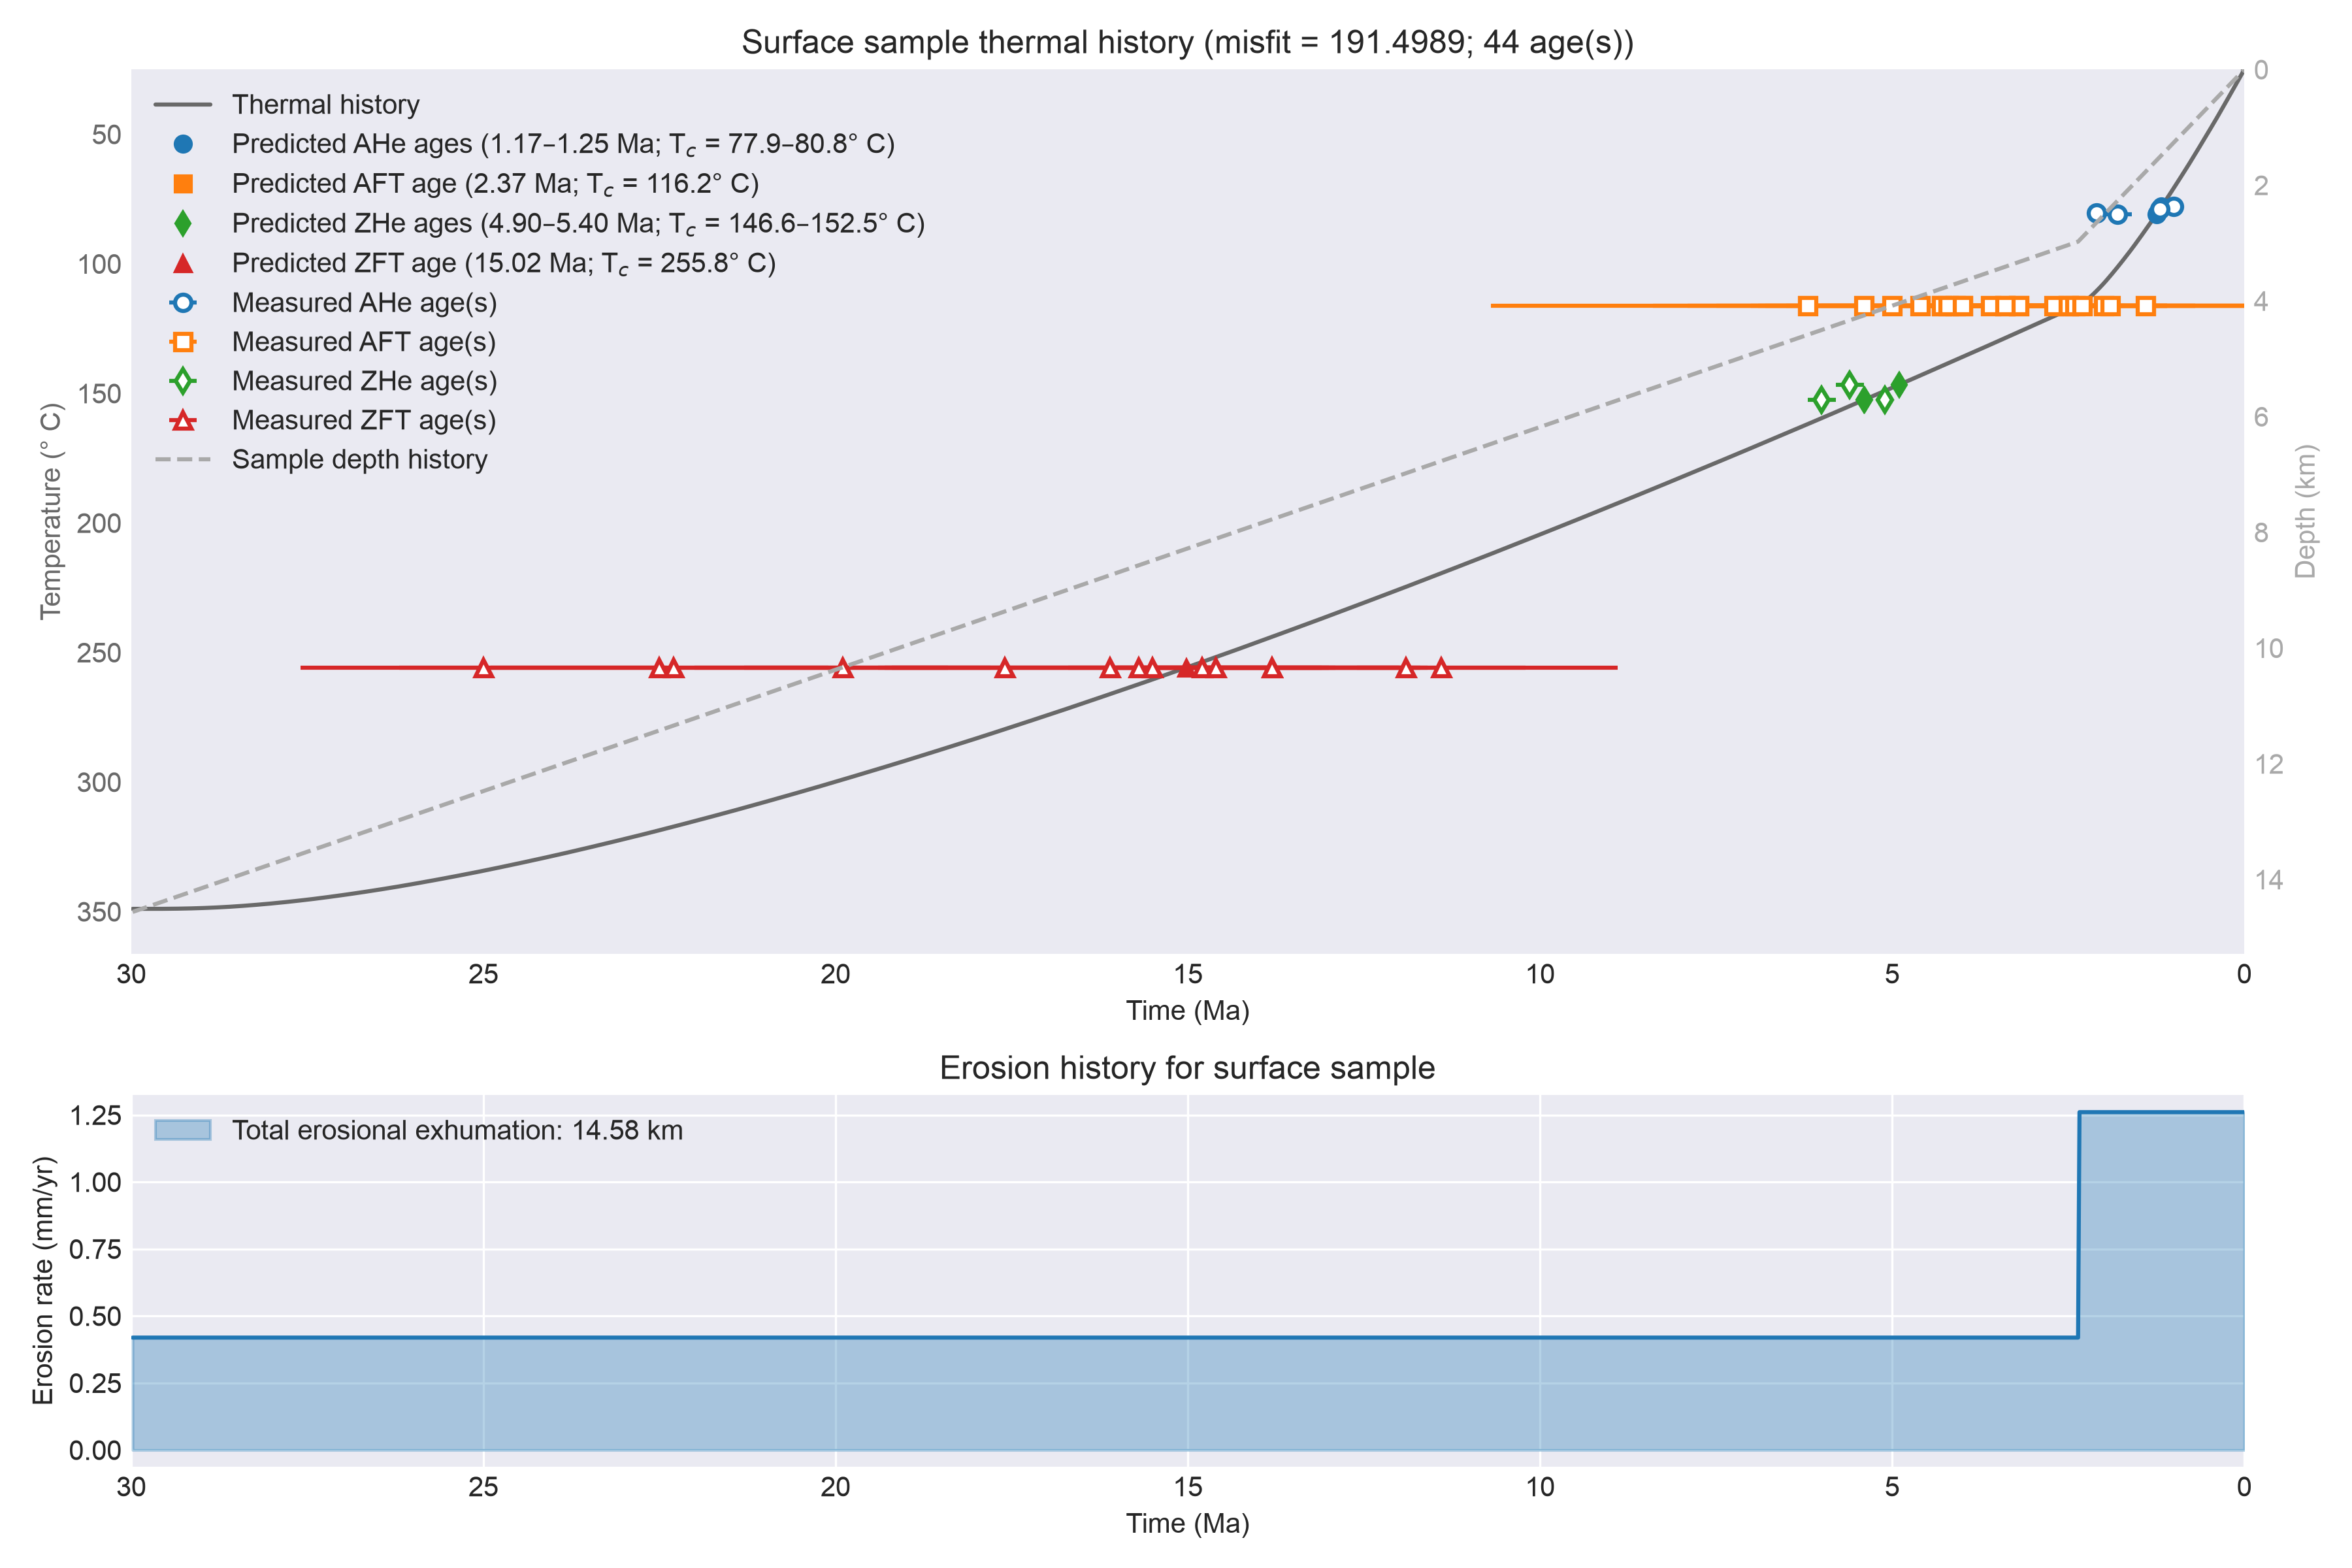

In [16]:
from IPython.display import Image, display

display(Image(filename="png/temperature_history.png"))
display(Image(filename="png/thermal_history.png"))